In [19]:
from caat import CAAT

def filter_sne(not_na_cols=[], **kwargs):

    caat = CAAT()
    filtered_sne = caat.get_list_of_sne(**kwargs)

    for col in not_na_cols:
        filtered_sne = filtered_sne.dropna(subset=[col])
    
    return filtered_sne

filter_sne(not_na_cols=["Filtmax"], Type="SESNe", Subtype="SNIb")


,Name,Type,Subtype,Redshift,RA,Dec,Tmax,Magmax,Filtmax
1,SN2004dk,SESNe,SNIb,0.005200,245.453880,-2.271470,53235.767258,15.810637,B
4,SN2022crv,SESNe,SNIb,0.008091,148.607958,-25.703100,59654.187835,15.447415,o
5,SN2007C,SESNe,SNIb,0.005611,197.205420,-6.783610,54118.300000,16.746993,g
6,SN2021uhk,SESNe,SNIb,0.035000,351.556648,1.145571,59437.254075,18.807625,g
7,SN2019yvr,SESNe,SNIb,0.005000,191.283897,-0.459120,58854.109192,16.062443,g
8,SN2023dtc,SESNe,SNIb,0.006000,128.323125,-22.962519,60036.148287,17.515727,g
9,SN2019dge,SESNe,SNIb,0.021300,264.194759,50.547811,58583.727828,18.514179,g
10,SN2019dgz,SESNe,SNIb,0.036400,184.019172,29.851698,58591.268081,19.200746,g
12,SN2009jf,SESNe,SNIb,0.005200,185.728875,15.823600,55121.245057,15.070219,V
14,SN2018beh,SESNe,SNIb,0.051000,142.845973,17.807700,58250.910498,17.771295,V


In [2]:
import os
import pandas as pd
from caat import SN
from caat.utils import WLE

"""
Make full sample LaTeX table

Prints LaTeX code to generate a table describing
every object in our sample.
Contains columns for name, type and subtype, redshift, peak information, 
number of detections, filters with detections, and phase range of detections.
"""

type_dict = {
    "SESNe": [
        "SNIIb",
        "SNIb",
        "SNIc"
    ]
}

# Print the header line of the table
print("Name & Type & Subtype & Redshift & Peak Date & Peak Magnitude & Peak Filter & # Detections & Filters with Detections & Phase of First Detection & Phase of Last Detection \\\\")

for typ, subtyp_list in type_dict.items():
    for subtyp in subtyp_list:
        sn_df = filter_sne(not_na_cols=["Filtmax", "Redshift"], Type=typ, Subtype=subtyp)
        for _, row in sn_df.iterrows():
            name = row["Name"]
            sn = SN(name=name)

            # Get number of detections
            data_cube_filename = os.path.join(
                sn.base_path,
                sn.classification,
                sn.subtype,
                sn.name,
                sn.name + "_datacube_mangled.csv"
            )
            if os.path.exists(data_cube_filename):
                cube = pd.read_csv(data_cube_filename)
                dets = cube[cube["Nondetection"] == False]  # noqa: E712
                number_of_dets = len(dets)

                # Get filters with detections
                filters_with_dets = list(set(dets["Filter"]))
                filter_list = sorted(filters_with_dets, key=lambda x: WLE.get(x, len(WLE)))
                filters = ",".join(filt for filt in filter_list)

                # Get phase of first and last detections
                phase_of_first_det = min(dets["Phase"])
                phase_of_last_det = max(dets["Phase"])

            else:
                print("Missing datacube for ", sn.name)

            print(f"{name} & {typ} & {subtyp} & {row['Redshift']} & {row['Tmax']} & {row['Magmax']} & {row['Filtmax']} & {number_of_dets} & {filters} & {phase_of_first_det} & {phase_of_last_det} \\\\")

Name & Type & Subtype & Redshift & Peak Date & Peak Magnitude & Peak Filter & # Detections & Filters with Detections & Phase of First Detection & Phase of Last Detection \\
SN2022ngb & SESNe & SNIIb & 0.009 & 59772.29063576007 & 16.74223392663918 & g & 270 & B,g,c,V,r,o,i & -1494.836040860173 & 367.9008584899202 \\
SN2020sbw & SESNe & SNIIb & 0.023033 & 59100.63095900752 & 18.69982321758331 & g & 214 & UVW2,UVM2,UVW1,U,B,g,c,r,o,i & -13.183748407383971 & 827.718273325816 \\
SN2009mg & SESNe & SNIIb & 0.004 & 55189.40591159596 & 15.61578639376763 & V & 81 & UVW2,UVW1,U,B,V & -13.487611595963244 & 1105.423588404039 \\
SN2021uqw & SESNe & SNIIb & 0.028019 & 59432.534540149936 & 17.980358589848503 & r & 42 & UVW2,UVM2,UVW1,U,B,g,r,i & -1142.0684174500348 & 25.76233485006378 \\
SN2011hs & SESNe & SNIIb & 0.0057 & 55887.92148458402 & 15.81004615782506 & V & 225 & UVW2,UVM2,UVW1,u',U,B,g',V,r',R,i',I,z' & -10.42148458401789 & 211.47851541598357 \\
SN2020rsc & SESNe & SNIIb & 0.0313 & 59097.28

In [27]:
import os
import requests


def query_ads(snname):
    """
    Query ADS for references to new classifications of the
    objects in our sample.
    Utilizes the ADS API to search for references to published
    works on the objects in our sample
    Returns a list of published, refereed papers for each of the
    objects in our sample.
    Relies on an ADS API token as an environment variable.
    """
    token = os.environ.get("ADS_API_TOKEN", None)
    if not token:
        raise Exception("Missing ADS API Token!")
    
    url = f"https://api.adsabs.harvard.edu/v1/search/query?q=abs:{snname}&fq=property:refereed&fl=bibcode,title"

    header = {"Authorization": f"Bearer {token}"}
    
    response = requests.get(url, headers=header)
    return response

cited_works = {}
sn_df = filter_sne(not_na_cols=["Filtmax", "Redshift"], Type="SESNe", Subtype="SNIIb")
for _, row in sn_df.iterrows():
    snname = row["Name"][:2] + " " + row["Name"][2:]
    response = query_ads(snname)
    if response.json()["response"]["numFound"] > 0:
        cited_works[snname] = response.json()["response"]["docs"]

In [26]:
response.json()

{'responseHeader': {'status': 0,
  'QTime': 35,
  'params': {'q': 'abs:SN 2008cw',
   'fl': 'bibcode',
   'start': '0',
   'internal_logging_params': 'X-Amzn-Trace-Id=Root=1-69669f8e-6e24cffe6db8eada4d7b9060',
   'fq': 'property:refereed',
   'rows': '10',
   'wt': 'json'}},
 'response': {'numFound': 0, 'start': 0, 'numFoundExact': True, 'docs': []}}

In [28]:
cited_works

{'SN 2009mg': [{'bibcode': '2012MNRAS.424.1297O',
   'title': ['Multiwavelength observations of the Type IIb supernova 2009mg']}],
 'SN 2011hs': [{'bibcode': '2014MNRAS.439.1807B',
   'title': ['SN 2011hs: a fast and faint Type IIb supernova from a supergiant progenitor']},
  {'bibcode': '2019MNRAS.485..102S',
   'title': ['The 3D shape of Type IIb SN 2011hs']}],
 'SN 2022hnt': [{'bibcode': '2025ApJ...984...60F',
   'title': ['Shock-cooling Constraints via Early-time Observations of the Type IIb SN 2022hnt']}],
 'SN 2016gkg': [{'bibcode': '2017ApJ...837L...2A',
   'title': ['Constraints on the Progenitor of SN 2016gkg from Its Shock-cooling Light Curve']},
  {'bibcode': '2017ApJ...846...94P',
   'title': ['Numerically Modeling the First Peak of the Type IIb SN 2016gkg']},
  {'bibcode': '2022MNRAS.517.1750A',
   'title': ['SN 2016iyc: a Type IIb supernova arising from a low-mass progenitor']},
  {'bibcode': '2018ApJ...852L..17S',
   'title': ['Constraints on the Progenitor System of SN 

/Users/craigpellegrino/github/nasa-adap/src/caat/SN.py:155: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


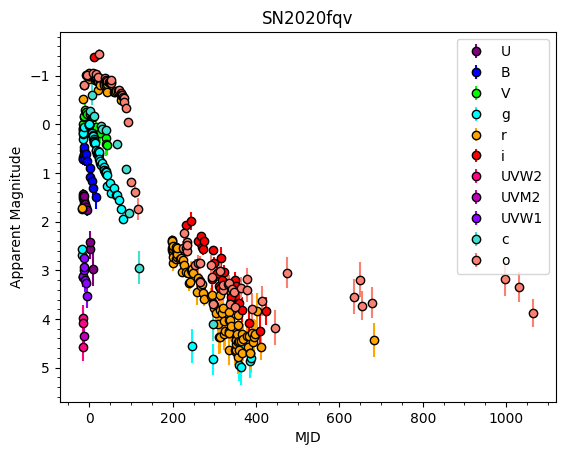

In [24]:
from caat import SN

sn = SN(name="SN2020fqv")
sn.plot_data(view_shifted_data=True)